# Parameter sweep in RF simulation

This notebook demonstrates how to perform parameter sweeps in RF simulations. Individual RF simulations are defined by `TerminalComponentModeler` (TCM) objects. To define a batch job, we simply construct a dictionary of TCM objects where each `(key, value)` pair contains a user-defined text label and the corresponding TCM object. Then, we use the usual `web.run()` command to submit this `dict` object instead of a single TCM. 

There are many different methods to generate the dictionary of TCM simulations. For basic parameter sweeps, one can define a parametric wrapper function to build the TCM for a given parameter value set. Then, use a basic `for` loop to iteratively build the dictionary. This workflow is demonstrated below. After the batch simulations are completed, we also demonstrate how to access the S-parameter and field monitor data. 

The workflow extends very easily to other design space exploration (DSE) algorithms. Simply replace the basic `for` loop with the appropriate logic for the DSE algorithm.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import tidy3d as td
import tidy3d.rf as rf
import tidy3d.web as web

td.config.logging.level = "ERROR"

Below, we set up some of the basic parameters of this demo. We will be constructing an edge-fed metal patch, and sweeping the width (y length) of the patch. 

<center><img src="./img/param_sweep_rf.png" width=540 /></center>

In [2]:
# Frequency range
f_min, f_max = (1e9, 20e9)
f0 = (f_max + f_min) / 2
freqs = np.linspace(f_min, f_max, 601)

# Geometry dimensions
mm = 1000
Lsub, Wsub = (20 * mm, 20 * mm)  # substrate dimensions
Hsub = 1.5 * mm  # substrate thickness
Hmetal = 0.035 * mm  # metal thickness
Lpatch = 8 * mm  # patch dimensions
Lfeed, Wfeed = ((Lsub - Lpatch) / 2, 2.9 * mm)  # feedline size

# Materials
metal = rf.LossyMetalMedium(conductivity=58, frequency_range=(f_min, f_max))
dielectric = td.Medium(permittivity=4.3)

## Defining a Parametric Wrapper Function

Instead of defining a static `TerminalComponentModeler`, we define a wrapper function `build_tcm()` that dynamically generates the TCM for a given `patch_width`. 

In [3]:
# Parametric function that generates a TerminalComponentModeler (TCM)
def build_tcm(patch_width):
    # Build structures
    substrate = td.Structure(
        geometry=td.Box(center=(0, 0, -Hsub / 2), size=(Lsub, Wsub, Hsub)), medium=dielectric
    )
    ground = td.Structure(
        geometry=td.Box(center=(0, 0, -Hsub - Hmetal / 2), size=(Lsub, Wsub, Hmetal)), medium=metal
    )
    feed = td.Structure(
        geometry=td.Box(
            center=(-Lpatch / 2 - Lfeed / 2, 0, Hmetal / 2), size=(Lfeed, Wfeed, Hmetal)
        ),
        medium=metal,
    )

    # Build patch (note use of input parameter patch_width)
    patch = td.Structure(
        geometry=td.Box(center=(0, 0, Hmetal / 2), size=(Lpatch, patch_width, Hmetal)), medium=metal
    )

    # Define port
    LP1 = rf.LumpedPort(
        center=(-Lsub / 2, 0, -Hsub / 2), size=(0, Wfeed, Hsub), voltage_axis=2, name="LP1"
    )

    # Define field monitor
    mon_1 = td.FieldMonitor(size=(td.inf, td.inf, 0), freqs=[f0], name="field (z=0)")

    # Define layer refinement
    lr_options = {
        "min_steps_along_axis": 1,
        "corner_refinement": td.GridRefinement(dl=0.15 * mm, num_cells=2),
    }
    layer_ref_1 = rf.LayerRefinementSpec.from_structures(structures=[feed, patch], **lr_options)
    layer_ref_2 = rf.LayerRefinementSpec.from_structures(structures=[ground], **lr_options)

    # Define grid
    grid_spec = td.GridSpec.auto(
        wavelength=td.C_0 / f0,
        min_steps_per_wvl=20,
        layer_refinement_specs=[layer_ref_1, layer_ref_2],
    )

    # Define simulation and TCM
    sim = td.Simulation(
        size=(30 * mm, 30 * mm, 8 * mm),
        structures=[substrate, ground, feed, patch],
        monitors=[mon_1],
        grid_spec=grid_spec,
        run_time=5e-9,
        plot_length_units="mm",
    )
    tcm = rf.TerminalComponentModeler(simulation=sim, ports=[LP1], freqs=freqs)

    # Return TCM object
    return tcm

## Generate Batch Dictionary

Using `build_tcm()`, we iteratively construct a dictionary `dict_tcm`, whose `(key, value)` pairs are given by a user-defined text label from `sweep_labels` and the respective TCM instance.

In [4]:
# Generate list of sweep values and corresponding labels
sweep_values = np.linspace(10 * mm, 12 * mm, 3)
sweep_labels = [f"patch_width={val / mm:.1f}mm" for val in sweep_values]

# Iteratively generate dict for batch job
dict_tcm = {}
for label, val in zip(sweep_labels, sweep_values):
    dict_tcm[label] = build_tcm(patch_width=val)

Before running, we can iterate over `dict_tcm` to inspect individual jobs.

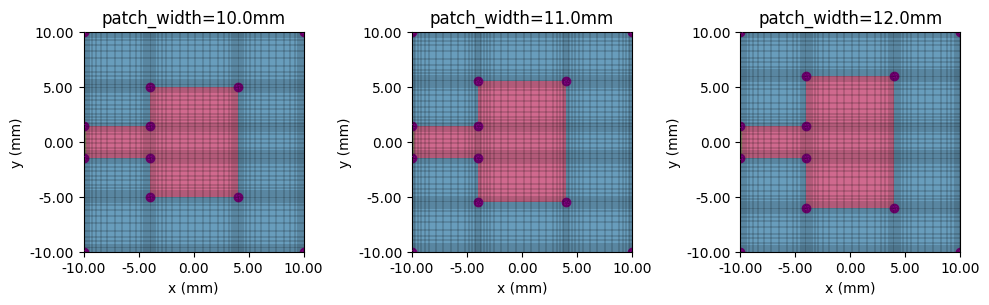

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(10, 6), tight_layout=True)
for ii, (label, tcm_plot) in enumerate(dict_tcm.items()):
    tcm_plot.plot_sim(z=0, ax=ax[ii], monitor_alpha=0)
    tcm_plot.simulation.plot_grid(z=0, ax=ax[ii])
    ax[ii].set_xlim(-Lsub / 2, Lsub / 2)
    ax[ii].set_ylim(-Wsub / 2, Wsub / 2)
    ax[ii].set_title(label)
plt.show()

## Submit Batch Job

We use the `web.run()` method to initiate the job. The syntax for submitting a batch TCM job is identical to that of submitting a single TCM job.

In [6]:
# Submit batch job
batch_tcm_data = web.run(dict_tcm, task_name="RF parameter sweep demo", path="./data")

Output()

15:49:08 EST Started working on Batch containing 3 tasks.

15:49:17 EST Maximum FlexCredit cost: 0.075 for the whole batch.

             Use 'Batch.real_cost()' to get the billed FlexCredit cost after    
             completion.

Output()

15:50:13 EST Batch complete.

## Process Batch Results

After a successful batch run, we use the returned `dict` object `batch_tcm_data` to access the result data. Its structure mirrors that of the dictionary `dict_tcm` that generated it - that is, one can access the individual job data using the same key label `tcm_data = batch_tcm_data[key_label]`. One can also iterate over all batch data using the `batch_tcm_data.items()` iterator, demonstrated below. 

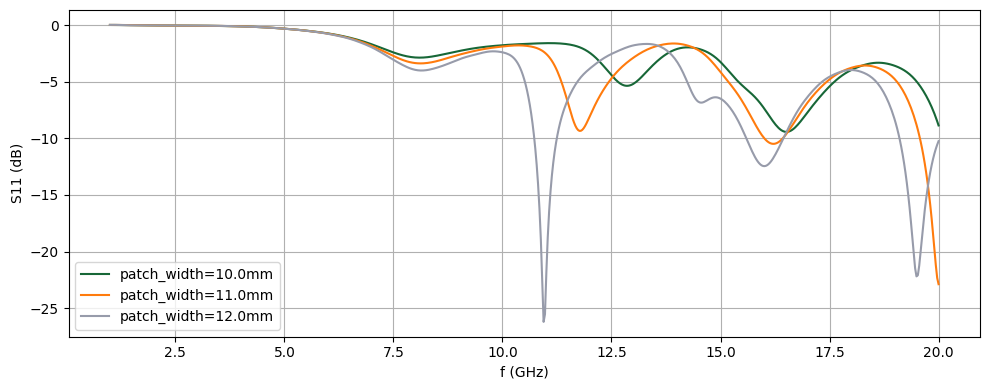

In [7]:
# Plot S11 comparison
fig, ax = plt.subplots(figsize=(10, 4), tight_layout=True)
for label, tcm_data_iter in batch_tcm_data.items():
    # Get S11 in dB
    S11 = tcm_data_iter.smatrix().data.squeeze()
    S11dB = 20 * np.log10(np.abs(S11))
    # Plot S11
    ax.plot(freqs / 1e9, S11dB, label=label)
ax.legend()
ax.grid()
ax.set_xlabel("f (GHz)")
ax.set_ylabel("S11 (dB)")
plt.show()

One can follow a similar process to access `FieldMonitor` data if present in the simulation. 

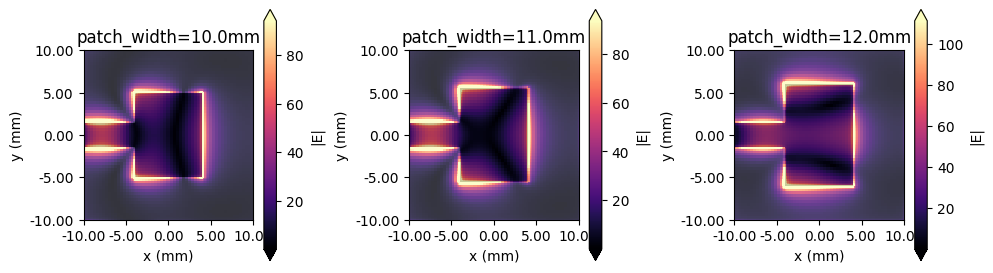

In [8]:
# Plot field monitor results
fig, ax = plt.subplots(1, 3, figsize=(10, 3), tight_layout=True)
for ii, (label, tcm_data_iter) in enumerate(batch_tcm_data.items()):
    sim_data = tcm_data_iter.data["LP1"]  # Get simulation data from port 1 excitation
    sim_data.plot_field("field (z=0)", field_name="E", val="abs", ax=ax[ii])
    ax[ii].set_xlim(-Lsub / 2, Lsub / 2)
    ax[ii].set_ylim(-Lsub / 2, Lsub / 2)
    ax[ii].set_title(label)
plt.show()